In [50]:
import pickle

import elegy
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from lgsm import PhysicsLayer
from matplotlib.backends.backend_pdf import PdfPages

In [7]:
model_dir = "../models/infoVAE_a1_lessReg_model/"
training_data = "../data/processed/simulated_photometry.pkl"

config = {
    "bandpasses": ["lsst"+b for b in "ugrizy"],
    "batch_size": 128,
}

bandpasses = config["bandpasses"]

In [36]:
# load the data
with open(training_data, "rb") as file:
    sims = pickle.load(file)

    # load the simulated photometry and redshifts
    redshift = jnp.array(sims["redshift"])
    photometry = jnp.array(sims["photometry"])
    idx = np.arange(redshift.size)
    data = jnp.hstack((idx.reshape(-1, 1), redshift.reshape(-1, 1), photometry))

    # load the simulated SEDs
    sim_wave = sims["sed_wave"]
    sim_sed = sims["sed_mag"]

# split the training and validation sets
val_split = 0.2
idx_split = int(redshift.size * (1 - val_split))
train_set = data[:idx_split]
val_set = data[idx_split:]

# set the number of points to plot
N = 1000

data = np.vstack((
    train_set[::config["batch_size"]][: N // 2], # training galaxies whose spectra were used in training
    train_set[1::config["batch_size"]][: N // 2], # training galaxies whose spectra were not used in training
    val_set[:(N - N // 2)], # validation galaxies
))

idx = data[:, 0]

data = pd.DataFrame(
    data[:, 1:],
    columns = ["redshift"] + bandpasses,
)

# record which set the galaxies come from
data["set"] = N * ["training"] + (N - N // 2) * ["validation"]

# record which galaxies had their spectra used in training
data["spectrum"] = N // 2 * [True] + N * [False]

# add observed colors to the DataFrame
colors = [f"{bandpasses[i]}-{bandpasses[i+1]}" for i in range(len(bandpasses) - 1)]
for i, color in enumerate(colors):
    data[color] = data[bandpasses[i]] - data[bandpasses[i+1]]

# calculate restframe colors
PL = PhysicsLayer(
    sed_wave=sim_wave,
    sed_unit="mag",
    bandpasses=config["bandpasses"],
    band_oversampling=3,
)
restframe_photometry = PL.call(
    sim_sed[idx.astype(int)], 
    np.zeros(idx.size).reshape(-1, 1), 
    np.zeros(idx.size).reshape(-1, 1)
)["predicted_photometry"]

restframe_colors = [f"restframe_{color}" for color in colors]
data[restframe_colors] = np.diff(restframe_photometry[::-1], axis=-1)

# strip lsst from all the column names for cleaner plotting
data.columns = [L.replace("lsst", "") for L in data.columns.tolist()]

In [37]:
# load the trained model
model = elegy.load(model_dir)
# make predictions
predictions = model.predict(data[["redshift"]+list("ugrizy")].to_numpy())
# save the latents
latents = pd.DataFrame(
    predictions["latent_mean"],
    columns=[f"s{i}" for i in range(predictions["latent_mean"].shape[1])]
)
# and the MSE
mse = np.mean(0.5 / 0.05**2 * (predictions["predicted_photometry"] - data.iloc[:, 1:7].to_numpy())**2, axis=-1)
mse = pd.DataFrame(mse, columns=["mse"])

data = pd.concat([data, latents, mse], axis=1)

In [79]:
figures = []

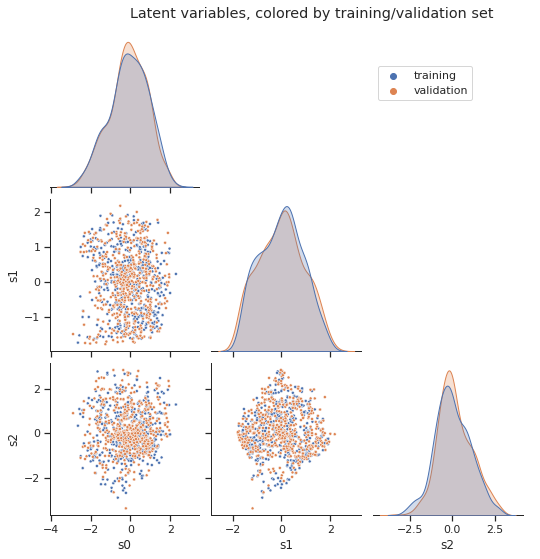

In [80]:
sns_theme = {
    "style": "ticks",
    "rc": {
        "axes.linewidth": 1,
    }
}
sns.set_theme(**sns_theme)

pg = sns.pairplot(
    data=data.query("spectrum == False"), hue="set", markers=".",
    corner=True, vars=["s0", "s1", "s2"]
)

handles = pg._legend_data.values()
labels = pg._legend_data.keys()
pg._legend.remove()
pg.fig.legend(handles, labels, loc=(0.7, 0.82))

pg.fig.suptitle("Latent variables, colored by training/validation set", y=1.03)

for ax in pg.axes.flatten():
    if ax is not None:
        ax.set_rasterized(True)

figures.append(pg)

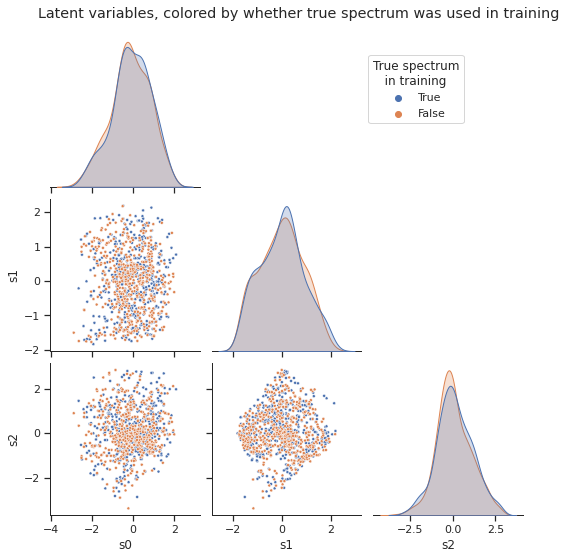

In [81]:
sns_theme = {
    "style": "ticks",
    "rc": {
        "axes.linewidth": 1,
    }
}
sns.set_theme(**sns_theme)

pg = sns.pairplot(
    data=pd.concat((
        data[:N//2],
        data[N - N//4: N + N//4],
    )),
    hue="spectrum", hue_order=[True, False], 
    markers=".", corner=True, 
    vars=["s0", "s1", "s2"]
)

handles = pg._legend_data.values()
labels = pg._legend_data.keys()
pg._legend.remove()
pg.fig.legend(
    handles, labels, loc=(0.65, 0.78), 
    title="True spectrum\n   in training"
)

pg.fig.suptitle("Latent variables, colored by whether true spectrum was used in training", y=1.03)

for ax in pg.axes.flatten():
    if ax is not None:
        ax.set_rasterized(True)

figures.append(pg)

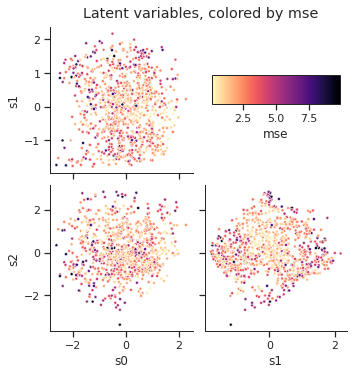

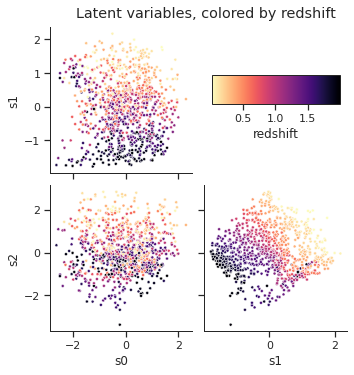

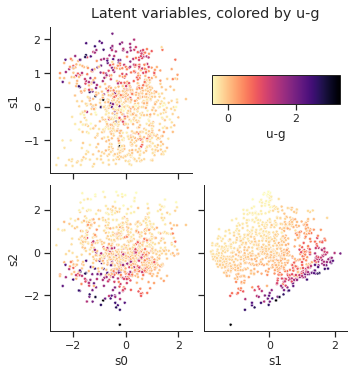

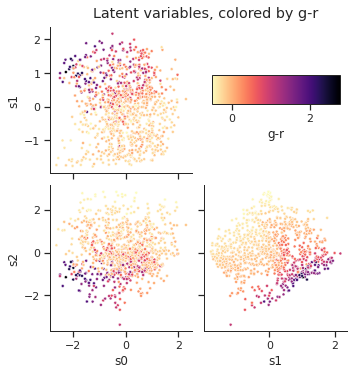

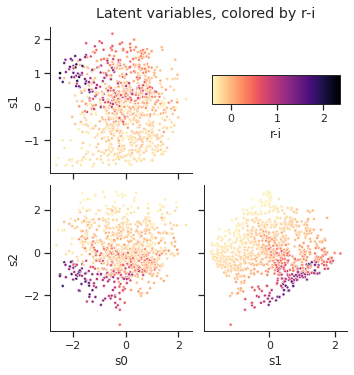

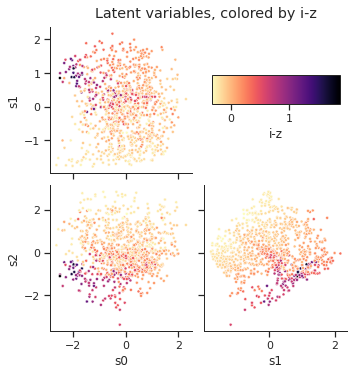

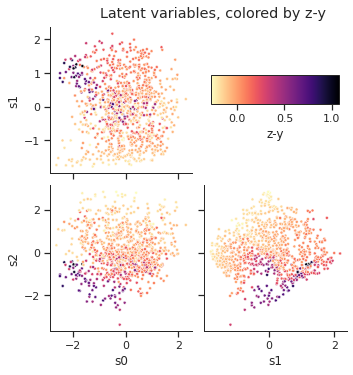

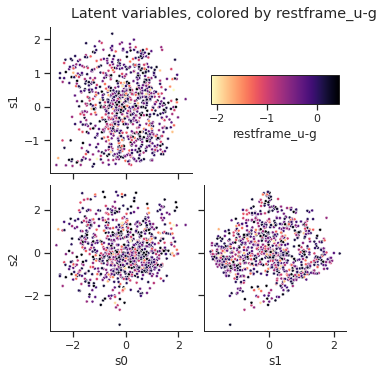

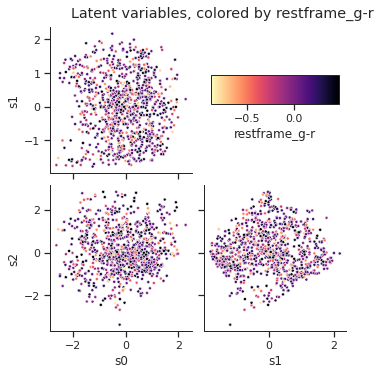

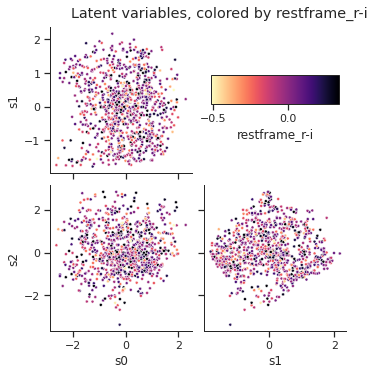

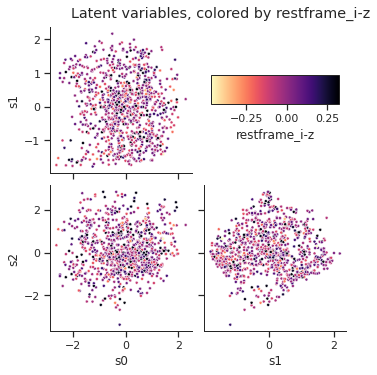

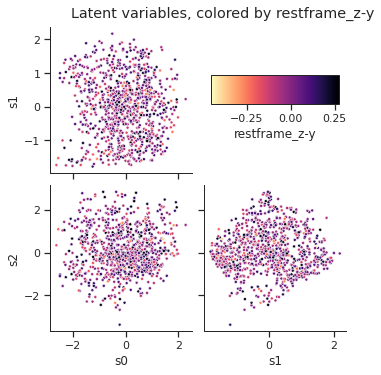

In [82]:
hue_vars = [
    "mse",
    "redshift", 
    "u-g", "g-r", "r-i", "i-z", "z-y",
    "restframe_u-g", "restframe_g-r", "restframe_r-i", "restframe_i-z", "restframe_z-y",
]

def pairplot_latents(hue_var, query="(spectrum == False) & (mse < 10)"):
    cmap = "magma_r"

    pg = sns.pairplot(
        data=data.query(query), hue=hue_var, markers=".", 
        palette=cmap,
        x_vars=["s0", "s1"],
        y_vars=["s1", "s2"],
        diag_kind=None
    )

    pg._legend.remove()
    norm = plt.Normalize(data.query(query)[hue_var].min(), data.query(query)[hue_var].max())
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    pg.axes[0, 1].remove()

    axins = inset_axes(
        pg.axes[1, 1],
        width="90%",
        height="20%",
        loc="upper center",
        borderpad=-10
    )
    pg.fig.colorbar(sm, cax=axins, label=hue_var, orientation="horizontal")

    pg.fig.suptitle(f"Latent variables, colored by {hue_var}", y=1.03)

    for ax in pg.axes.flatten():
        ax.set_rasterized(True)
    #axins.set_rasterized(True)

    return pg


for var in hue_vars:
    figures.append(pairplot_latents(var))

In [83]:
with PdfPages("test.pdf") as pdf:
    for pg in figures:
        pdf.savefig(pg.fig, bbox_inches='tight', dpi=200)